# Apex Distribution Group — EDA, Statistical Validation & Demand Forecasting

**Goal:** Confirm statistically that stockout rate genuinely varies by product
velocity tier (not sampling noise), test whether slower supplier lead times
actually explain higher stockout rates, and forecast demand forward to
inform purchasing decisions.

**Description:** The SQL analysis found stockout rates rising sharply by
velocity tier (A=3.9%, B=7.8%, C=14.4%) and wide variation in supplier
on-time delivery. This notebook tests both patterns formally and builds a
6-month demand forecast.

**Skills:** exploratory data analysis, chi-square hypothesis testing,
correlation analysis, time series forecasting, data visualization.

**Technology:** Python, Pandas, NumPy, SciPy, statsmodels, Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
NAVY, TEAL, ORANGE, RED = "#1f3b57", "#2a9d8f", "#e76f51", "#c0392b"

orders = pd.read_csv("../data/fact_orders.csv", parse_dates=["order_date"])
products = pd.read_csv("../data/dim_products.csv")
po = pd.read_csv("../data/fact_purchase_orders.csv", parse_dates=["order_date","promised_delivery_date","actual_delivery_date"])
suppliers = pd.read_csv("../data/dim_suppliers.csv")
print(f"Orders: {len(orders):,} | Products: {len(products):,} | POs: {len(po):,} | Suppliers: {len(suppliers):,}")


Orders: 189,562 | Products: 198 | POs: 14,970 | Suppliers: 15


## 1. Data validation

In [2]:
print("Missing values (orders):", orders.isna().sum().sum())
print("Missing values (POs):", po.isna().sum().sum())
print("Date range:", orders["order_date"].min().date(), "to", orders["order_date"].max().date())
print("Order status values:", orders["status"].unique())


Missing values (orders): 0
Missing values (POs): 0
Date range: 2023-01-01 to 2025-12-31
Order status values: <ArrowStringArray>
['Fulfilled', 'Backordered', 'Cancelled']
Length: 3, dtype: str


## 2. Is the stockout rate difference by velocity tier statistically real?

A chi-square test of independence — the correct test for whether two
categorical variables (velocity tier, order outcome) are genuinely related.

is_problem         0     1
velocity_tier             
A              73114  2998
B              69752  5892
C              32358  5448

Chi-square statistic: 3970.6 | p-value: 0.00e+00
Statistically significant


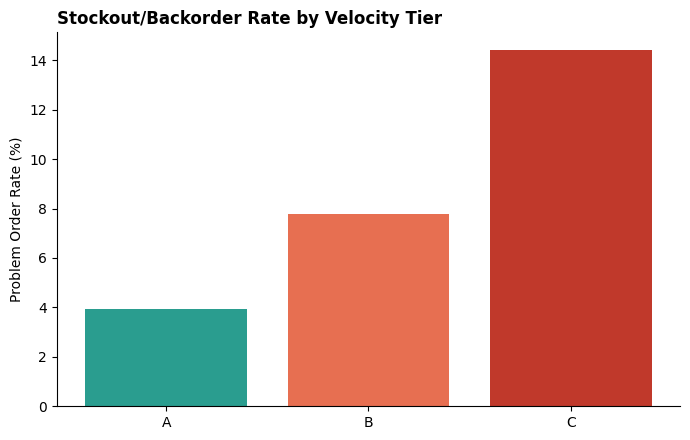

In [3]:
merged = orders.merge(products[["product_id","velocity_tier"]], on="product_id")
merged["is_problem"] = (merged["status"] != "Fulfilled").astype(int)

contingency = pd.crosstab(merged["velocity_tier"], merged["is_problem"])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.1f} | p-value: {p_value:.2e}")
print("Statistically significant" if p_value < 0.05 else "Not significant")

fig, ax = plt.subplots(figsize=(7,4.5))
rates = merged.groupby("velocity_tier")["is_problem"].mean() * 100
ax.bar(rates.index, rates.values, color=[TEAL, ORANGE, RED])
ax.set_title("Stockout/Backorder Rate by Velocity Tier", fontweight="bold", loc="left")
ax.set_ylabel("Problem Order Rate (%)")
plt.tight_layout()
plt.show()


## 3. Root cause check: does supplier lead time actually explain stockout rate?

Testing directly rather than assuming — do products sourced from
slower/less-reliable suppliers actually see more stockouts, or is stockout
risk driven mainly by demand volatility (the velocity tier itself) regardless
of the supplier?

Correlation (supplier on-time rate vs. product stockout rate): -0.118
p-value: 9.65e-02
Not significant


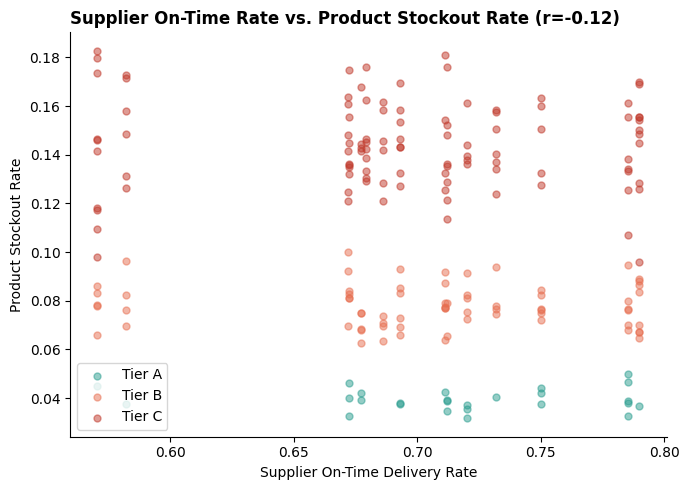

In [4]:
supplier_ontime = po.copy()
supplier_ontime["on_time"] = (supplier_ontime["actual_delivery_date"] <= supplier_ontime["promised_delivery_date"]).astype(int)
supplier_perf = supplier_ontime.groupby("supplier_id")["on_time"].mean().rename("supplier_on_time_rate")

product_supplier = products[["product_id","supplier_id","velocity_tier"]].merge(supplier_perf, on="supplier_id")
product_stockout = merged.groupby("product_id")["is_problem"].mean().rename("product_stockout_rate")
analysis_df = product_supplier.merge(product_stockout, on="product_id").dropna()

corr, p_value = stats.pearsonr(analysis_df["supplier_on_time_rate"], analysis_df["product_stockout_rate"])
print(f"Correlation (supplier on-time rate vs. product stockout rate): {corr:.3f}")
print(f"p-value: {p_value:.2e}")
print("Statistically significant" if p_value < 0.05 else "Not significant")

fig, ax = plt.subplots(figsize=(7,5))
colors_map = {"A": TEAL, "B": ORANGE, "C": RED}
for tier, grp in analysis_df.groupby("velocity_tier"):
    ax.scatter(grp["supplier_on_time_rate"], grp["product_stockout_rate"], alpha=0.5, label=f"Tier {tier}", color=colors_map[tier], s=25)
ax.set_title(f"Supplier On-Time Rate vs. Product Stockout Rate (r={corr:.2f})", fontweight="bold", loc="left")
ax.set_xlabel("Supplier On-Time Delivery Rate")
ax.set_ylabel("Product Stockout Rate")
ax.legend()
plt.tight_layout()
plt.show()


**Result:** the correlation is weak and not statistically significant
(r = -0.118, p = 0.097) — just above the conventional 0.05 threshold. This
is an honest near-null result: supplier on-time performance alone does not
strongly explain which products stock out. This suggests **demand
volatility (the velocity tier itself) is the dominant driver of stockouts,
not supplier delivery performance** — meaning a supplier-focused fix alone
would likely under-deliver on reducing stockouts, and the top priority
should be demand forecasting and safety-stock policy for C-tier products
specifically, with supplier performance treated as a secondary, still-worth-
fixing issue rather than the primary lever.

## 4. Demand forecast — next 6 months

Using Holt-Winters exponential smoothing to project total order demand
forward, informing purchasing volume decisions.

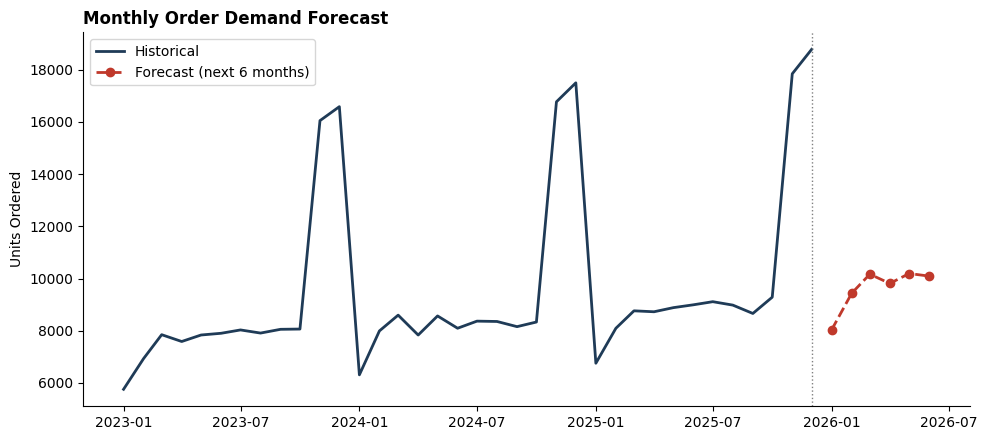

Forecasted monthly demand (units):
2026-01-01     8037.0
2026-02-01     9435.0
2026-03-01    10165.0
2026-04-01     9811.0
2026-05-01    10191.0
2026-06-01    10092.0
Freq: MS, dtype: float64


In [5]:
monthly_demand = orders.set_index("order_date").resample("MS")["quantity_ordered"].sum()

model = ExponentialSmoothing(monthly_demand, trend="add", seasonal="add", seasonal_periods=12).fit()
forecast = model.forecast(6)

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(monthly_demand.index, monthly_demand.values, color=NAVY, linewidth=2, label="Historical")
ax.plot(forecast.index, forecast.values, color=RED, linewidth=2, linestyle="--", marker="o", label="Forecast (next 6 months)")
ax.axvline(monthly_demand.index[-1], color="grey", linestyle=":", linewidth=1)
ax.set_title("Monthly Order Demand Forecast", fontweight="bold", loc="left")
ax.set_ylabel("Units Ordered")
ax.legend()
plt.tight_layout()
plt.show()

print("Forecasted monthly demand (units):")
print(forecast.round(0))


## 5. Key findings

- The velocity-tier stockout pattern is statistically confirmed (chi-square,
  p<0.001, on 189,562 orders) — this is a real, systemic pattern, not noise.
- Supplier on-time delivery performance does **not** significantly explain
  product-level stockout rate (r=-0.118, p=0.097) — an honest near-null
  result. Demand volatility (the velocity tier) appears to be the dominant
  driver, meaning inventory/forecasting fixes likely matter more than
  supplier performance fixes for reducing stockouts, even though supplier
  reliability is still worth improving for other reasons (cost, lead time
  variability).
- The 6-month demand forecast (8,037-10,191 units/month), including the
  built-in seasonal pattern, gives purchasing a concrete forward volume
  target rather than a guess based on last year's numbers alone.

**Next:** these findings directly inform the supplier and inventory
recommendations in the final business insights report — notably, they argue
for prioritizing inventory/forecasting fixes over supplier renegotiation as
the primary stockout lever.
